## Momentum
1. 一阶动量：最新一期动量与过去动量的差值(1 day)，并进行指数加权移动平均

   （EWMA: ma_window=20, ewma_span=5）

2. 二阶动量：最新一期动量与过去动量的差值(1 day)，并进行指数加权移动平均

   （EWMA: ma_window=20, ewma_span=5）

因子分析报告: factor

IC统计:
平均IC: 0.0045
IC标准差: 0.2156
ICIR: 0.0208
IC胜率: 51.13%
显著IC胜率 (p<0.05): 57.90%

多空方向判断: LS

分组收益统计（每组）:
Group_1: 年化收益=6.31%, 夏普=0.18
Group_2: 年化收益=15.70%, 夏普=0.45
Group_3: 年化收益=15.87%, 夏普=0.45
Group_4: 年化收益=18.26%, 夏普=0.54
Group_5: 年化收益=24.84%, 夏普=0.74

多空策略（方向=LS）: 年化收益=-18.53%, 夏普=-1.03

分月份IC统计:
月度IC均值: 0.0051
月度IC标准差: 0.0541
月度ICIR: 0.0936


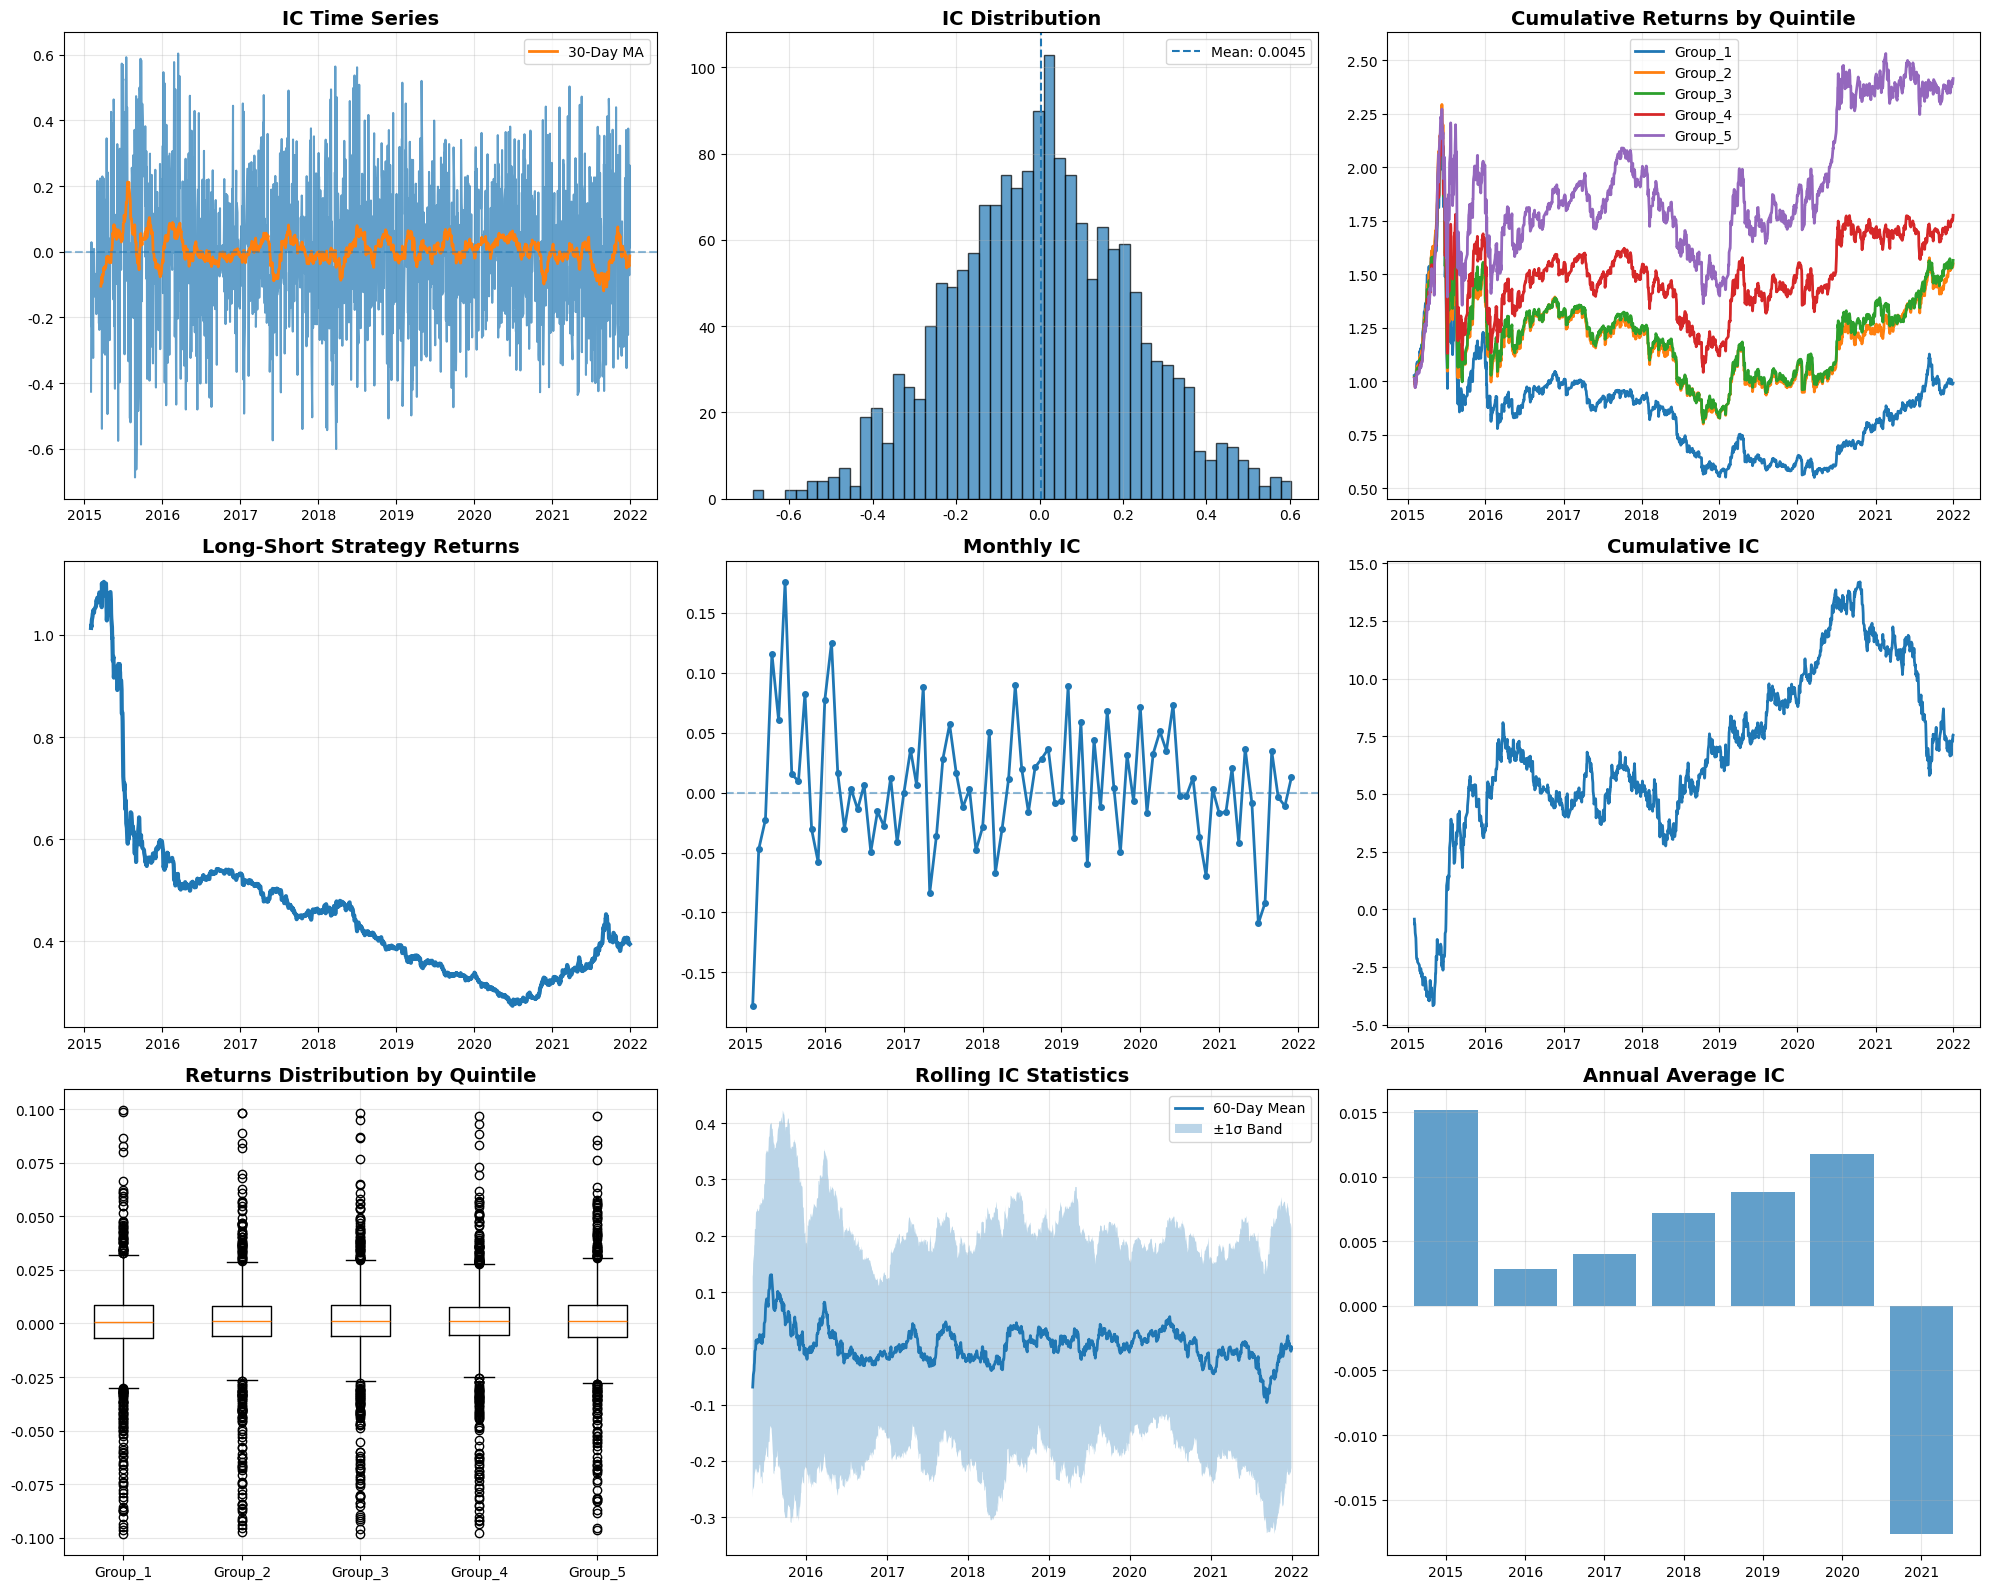

因子分析报告: factor_rank

IC统计:
平均IC: -0.0045
IC标准差: 0.2156
ICIR: -0.0208
IC胜率: 48.87%
显著IC胜率 (p<0.05): 57.90%

多空方向判断: SL

分组收益统计（每组）:
Group_1: 年化收益=24.73%, 夏普=0.74
Group_2: 年化收益=18.19%, 夏普=0.54
Group_3: 年化收益=15.72%, 夏普=0.45
Group_4: 年化收益=16.55%, 夏普=0.47
Group_5: 年化收益=5.91%, 夏普=0.17

多空策略（方向=SL）: 年化收益=-18.83%, 夏普=-1.06

分月份IC统计:
月度IC均值: -0.0051
月度IC标准差: 0.0541
月度ICIR: -0.0936


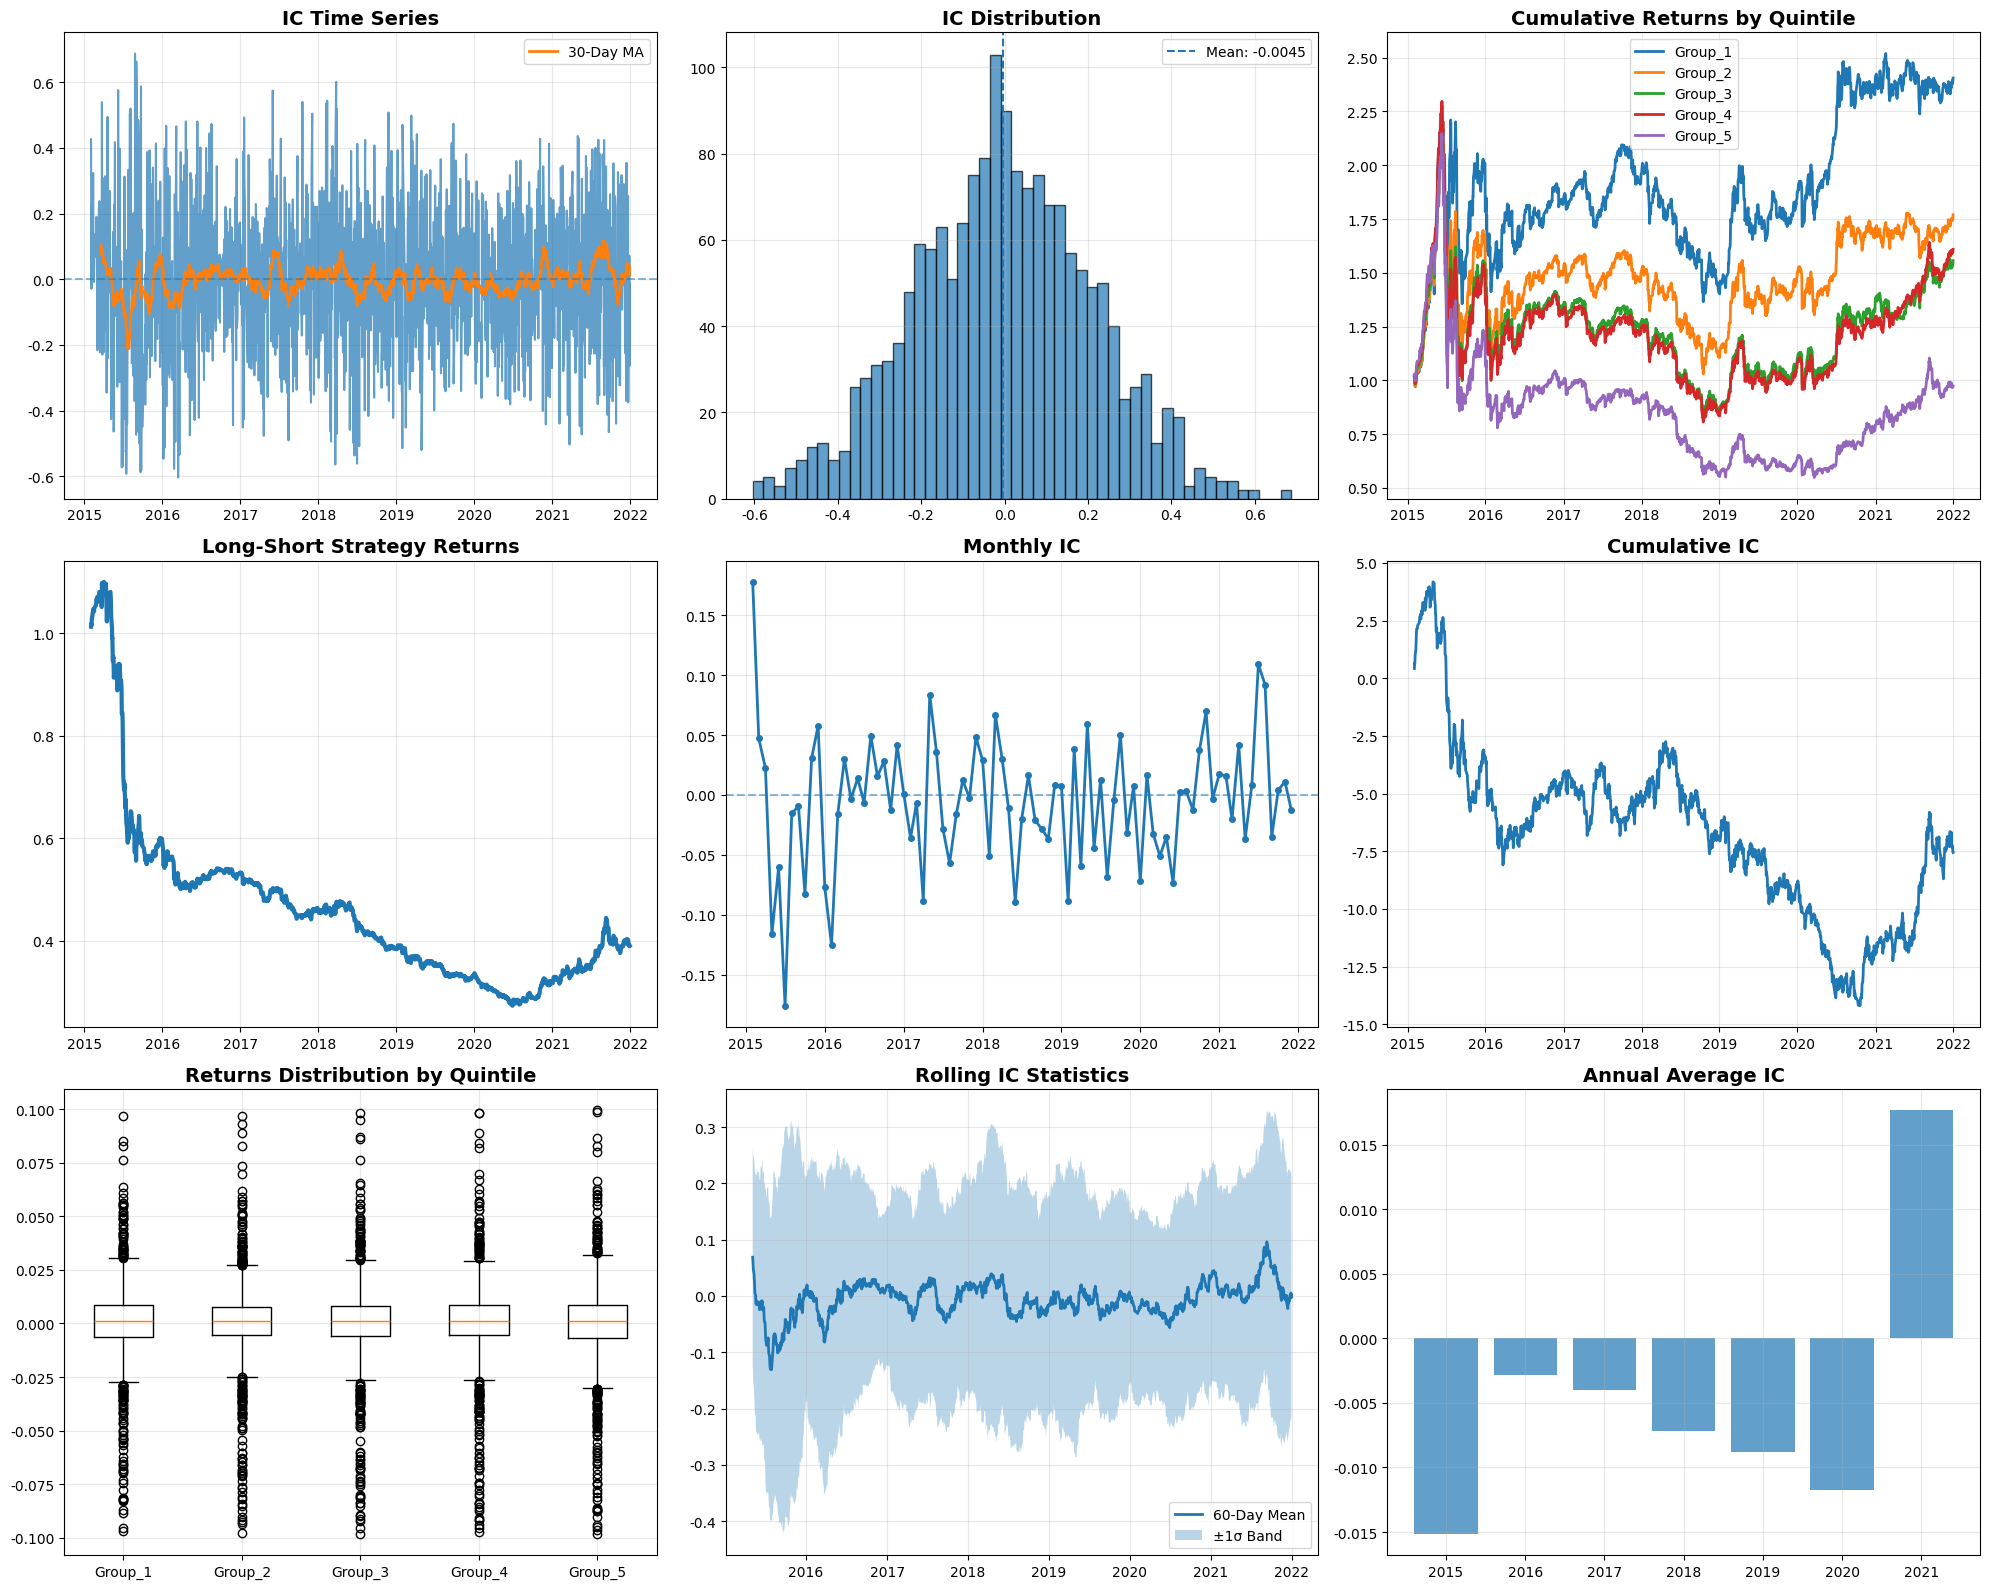

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from alpha_analysis import FactorAnalysis as FA
from write_alpha import load_data

def calculate_second_order_momentum(price_series, ma_window, ewma_span):
    """计算二阶动量"""
    past_price_avg = price_series.rolling(window=ma_window, min_periods=20).mean()
    momentum = (price_series - past_price_avg) / past_price_avg
    momentum_diff = momentum.diff()
    second_order_momentum = momentum_diff.ewm(span=ewma_span, adjust=False).mean()
    return second_order_momentum

df, alpha = load_data('2015-01-01', '2021-12-31')
df['factor'] = df.groupby('idx')['open'].transform(
    lambda x: calculate_second_order_momentum(x, ma_window=20, ewma_span=5)
)
df['factor_rank'] = df.groupby('Time')['factor'].rank(method='dense', ascending=False)

analysis_df = pd.merge(df, alpha, on=['Time', 'idx'], how='inner')

factor_analyzer = FA(analysis_df, factor_col='factor', return_col='next_return', time_col='Time')
factor_analyzer.plot_analysis(*factor_analyzer.run_full_analysis(n_groups=5))

factor_rank_analyzer = FA(analysis_df, factor_col='factor_rank', return_col='next_return', time_col='Time')
factor_rank_analyzer.plot_analysis(*factor_rank_analyzer.run_full_analysis(n_groups=5))
